# Transformers: character-level language model
## Yoav Ram

We will see here the [**Transformer** architecture](https://en.wikipedia.org/wiki/Transformer_(deep_learning_architecture)).
Transformers are the basis of large language models like [GPT](https://en.wikipedia.org/wiki/Generative_pre-trained_transformer)--the "T" stands for "Transformer".

Here, we apply transformers to the same problem we applied RNN and GRU: text generation by pretraining a character level model.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" # jax compiler messages
os.environ["GRPC_VERBOSITY"] = "ERROR"  # if gRPC noise too
# os.environ['JAX_PLATFORMS'] = 'cpu' # force cpu

import jax
import jax.numpy as jnp
print('jax', jax.__version__, jax.default_backend())
import optax
import numpy as np          # real NumPy, for the data pipeline; jnp is JAX

import glob
import hashlib
import json
import pickle

jax 0.9.2 gpu


# Data: the shared experiment

Like `GRU.ipynb`, this notebook does **not** define its own data. `RNN.ipynb` defines the experiment all three character-level notebooks share and writes it out; we load it.

This matters most here. A transformer has no hidden state to carry between windows, so the shared `state_policy` is `'none'` — every window starts cold, for every model. The earlier version of this comparison streamed the whole corpus through the RNN and GRU while giving the transformer short windows from a zero context, and then reported the three losses side by side. That is a difference in protocol, not in architecture.

If the artifacts are missing, the cell below **fails loudly** rather than re-deriving a split of its own.

In [2]:
SPLIT_PATH = 'checkpoints/charlm_split.npz'
CONFIG_PATH = 'checkpoints/charlm_config.json'

for path in (SPLIT_PATH, CONFIG_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{path} is missing. Run RNN.ipynb first: it defines the shared '
            'experiment (split, budget, state policy, seed) that this notebook '
            'must reproduce exactly for the comparison to mean anything.')

with open(CONFIG_PATH) as f:
    CONFIG = json.load(f)

split = np.load(SPLIT_PATH, allow_pickle=False)
train_tokens, val_tokens = split['train'], split['val']
chars = [str(c) for c in split['vocab']]
vocab_size = len(chars)
int_to_char = dict(enumerate(chars))
char_to_int = {c: i for i, c in int_to_char.items()}

def array_hash(a):
    return hashlib.sha256(np.ascontiguousarray(a).tobytes()).hexdigest()[:16]

if array_hash(val_tokens) != CONFIG['val_hash']:
    raise ValueError(
        'charlm_split.npz and charlm_config.json disagree: the validation array '
        f"hashes to {array_hash(val_tokens)} but the config records "
        f"{CONFIG['val_hash']}. Re-run RNN.ipynb to regenerate both together.")

print(f"corpus {CONFIG['corpus']}  |  vocabulary {vocab_size}")
print(f"train {len(train_tokens):,} characters  |  val {len(val_tokens):,}  "
      f"|  val_hash {CONFIG['val_hash']}")
print(f"context {CONFIG['context_length']}  |  batch {CONFIG['batch_size']}  "
      f"|  steps {CONFIG['steps']:,}  |  state_policy {CONFIG['state_policy']}  "
      f"|  seed {CONFIG['seed']}")

corpus data/shakespear3.txt  |  vocabulary 67
train 4,116,005 characters  |  val 457,333  |  val_hash b73fdb99e3a24d33
context 128  |  batch 64  |  steps 10,000  |  state_policy none  |  seed 42


The split arrives already encoded as integers, one `uint8` per character. The helpers below are this notebook's own copies of the sampler, the bits-per-character metric and the evaluator — identical in behaviour to the ones in `RNN.ipynb` and `GRU.ipynb`, and checked against the same uniform-model assertion.

In [3]:
def decode(ids):
    return ''.join(int_to_char[int(i)] for i in ids)

# The model below still consumes one-hot vectors. We materialise them per window,
# never for the whole corpus; the next revision of this notebook removes them.
def onehot(ids):
    return jax.nn.one_hot(jnp.asarray(ids, dtype=jnp.int32), vocab_size)

def onehot_decode(arr):
    return decode(np.asarray(arr).argmax(axis=-1))

def sample_batch(rng, tokens, batch_size, context_length):
    """Draw a batch of random windows. Returns (inputs, targets), both (B, T)."""
    hi = len(tokens) - context_length - 1
    start = rng.integers(0, hi, size=batch_size)
    idx = start[:, None] + np.arange(context_length + 1)[None, :]
    window = tokens[idx]
    return window[:, :-1].astype(np.int32), window[:, 1:].astype(np.int32)

def bits_per_char(total_nats, n_chars):
    return total_nats / n_chars / np.log(2)

def windows(tokens, context_length):
    n = (len(tokens) - 1) // context_length
    idx = np.arange(n * context_length).reshape(n, context_length)
    return tokens[idx].astype(np.int32), tokens[idx + 1].astype(np.int32)

def evaluate_bpc(logprob_fn, tokens, context_length, batch_size=64):
    """Mean bits per character, scored on the same windows as every other model,
    with nothing carried between windows (state_policy='none')."""
    x, y = windows(tokens, context_length)
    total_nats, n = 0.0, 0
    for i in range(0, len(x), batch_size):
        xb, yb = x[i:i + batch_size], y[i:i + batch_size]
        logp = np.asarray(logprob_fn(xb))
        picked = np.take_along_axis(logp, yb[:, :, None], axis=-1)[:, :, 0]
        total_nats += -picked.sum()
        n += picked.size
    return bits_per_char(total_nats, n)

def write_result(model, bpc, n_params=None, **extra):
    record = {'model': model, 'bpc': float(bpc), 'n_params': n_params,
              'manifest': dict(CONFIG), **extra}
    with open(f'checkpoints/charlm_result_{model}.json', 'w') as f:
        json.dump(record, f, indent=2)
    return record

# the evaluator must reproduce the known answer for a uniform model
uniform = lambda x: np.full(x.shape + (vocab_size,), -np.log(vocab_size))
assert np.isclose(evaluate_bpc(uniform, val_tokens, CONFIG['context_length']),
                  np.log2(vocab_size))
print('evaluator agrees with log2(V) on a uniform model')

evaluator agrees with log2(V) on a uniform model


# Text transformer
Unlike RNN and GRU which process sequences step by step maintaining a hidden state, the Transformer processes the entire sequence at once using **self-attention** — each position can directly attend to all previous positions.

## Self-attention

For each position $i$ in the input sequence $x$, we compute **query**, **key**, and **value** vectors:
$$
q_i = W^q x_i, \quad k_j = W^k x_j, \quad v_j = W^v x_j
$$

The **attention weight** of position $i$ to position $j$ is:
$$
w_{ij} = \text{softmax}_j\left(\frac{q_i \cdot k_j}{\sqrt{d_k}}\right)
$$

The output for position $i$ is a weighted sum of values: $z_i = \sum_j w_{ij} v_j$.

A **causal mask** ensures position $i$ only attends to $j \le i$, preserving the autoregressive property (just as in RNN/GRU, character $i$ depends on $j < i$ but not $j > i$).

In **multi-head** attention, we split $q$, $k$, $v$ into multiple heads that attend independently, then concatenate their outputs. This allows the model to attend to different types of relationships simultaneously.


In [4]:
def self_attention(x, W_q, W_k, W_v, W_o, n_heads):
    seq_len, d_model = x.shape
    d_head = d_model // n_heads
    
    Q = x @ W_q  # (seq_len, d_model)
    K = x @ W_k
    V = x @ W_v
    
    # reshape to (n_heads, seq_len, d_head) - no batch dimension
    Q = Q.reshape(seq_len, n_heads, d_head).transpose(1, 0, 2)
    K = K.reshape(seq_len, n_heads, d_head).transpose(1, 0, 2)
    V = V.reshape(seq_len, n_heads, d_head).transpose(1, 0, 2)
    
    # attention weights
    w_logits = (Q @ K.transpose(0, 2, 1)) / jnp.sqrt(d_head)  # (n_heads, seq_len, seq_len)
    # causal mask
    mask = jnp.tril(jnp.ones((seq_len, seq_len)))
    w_logits = w_logits - 1e10 * (1 - mask)
    w = jax.nn.softmax(w_logits, axis=-1)
    
    # weighted sum of values
    z = w @ V  # (n_heads, seq_len, d_head)
    # concatenate heads
    z = z.transpose(1, 0, 2).reshape(seq_len, d_model)
    
    return z @ W_o

## Transfomer blocks

Each transformer block applies:
1. Layer normalization → multi-head self-attention → residual connection
2. Layer normalization → feed-forward network → residual connection

In [5]:
def layer_norm(x, eps=1e-6):
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.mean((x - mean) ** 2, axis=-1, keepdims=True)
    return (x - mean) / jnp.sqrt(var + eps)

In [6]:
def transformer_block(x, params, n_heads):
    # self-attention with pre-norm and residual
    x_norm = layer_norm(x)
    x = x + self_attention(x_norm, params['W_q'], params['W_k'],  params['W_v'], params['W_o'], n_heads)
    # feed-forward network with pre-norm and residual connection
    x_norm = layer_norm(x)
    h = jax.nn.relu(x_norm @ params['W1'] + params['b1'])
    x = x + h @ params['W2'] + params['b2']
    return x

def init_layer_params(key, d_model, d_ff):
    keys = jax.random.split(key, 6)
    return {
        'W_q': jax.random.normal(keys[0], (d_model, d_model)) * 0.02,
        'W_k': jax.random.normal(keys[1], (d_model, d_model)) * 0.02,
        'W_v': jax.random.normal(keys[2], (d_model, d_model)) * 0.02,
        'W_o': jax.random.normal(keys[3], (d_model, d_model)) * 0.02,
        'W1': jax.random.normal(keys[4], (d_model, d_ff)) * 0.02,
        'b1': jnp.zeros((d_ff,)),
        'W2': jax.random.normal(keys[5], (d_ff, d_model)) * 0.02,
        'b2': jnp.zeros((d_model,)),
    }


## Transformer classifier

The full model stacks transformer blocks. Unlike RNN and GRU, where the input weight matrix $W_x^h$ implicitly serves as an embedding (since $W_x^h\,\text{onehot}(c)$ selects column $c$), the transformer has no per-step input matrix — it applies the same computation to every position. It therefore needs an explicit **learned token embedding**, which is the *same operation* the RNN writes as `Wxh[:, x_id]`, just named differently.

It also needs a **learned positional embedding**, because self-attention is permutation-**equivariant**: permute the input positions and the outputs come out permuted the same way, not unchanged. (Invariance would mean the output does not move at all — that is what `sets.ipynb` builds, and it is exactly what a language model must *not* have.) Attention alone therefore has no notion of order, and the position embedding supplies it.

### Depth, and why this notebook uses one block

An earlier version stacked **5 blocks** while the RNN and GRU each had a single recurrent layer, so the transformer was both wider in total parameters and five times deeper. That table could not distinguish "attention beats recurrence" from "deep beats shallow".

Here all three models are **one layer deep** and matched to the same parameter budget (`CONFIG['param_budget']`), so the only thing that varies is the mechanism. The cost is that a one-block transformer is not what anyone ships — depth is much of what makes transformers work — so the exercises at the end put the depth back and measure what it buys.

In [7]:
def transformer_model(params, ids, n_heads):
    """One window. ids (T,) of ints -> logits (T, V)."""
    seq_len = ids.shape[0]
    # token embedding + positional embedding.
    # token_emb[ids] is the same column lookup the RNN writes as Wxh[:, x_id]:
    # an embedding table IS the input weight matrix of a one-hot model.
    x = params['token_emb'][ids] + params['pos_emb'][:seq_len]
    for layer_params in params['layers']:
        x = transformer_block(x, layer_params, n_heads)
    # final layer norm and classifier head that outputs logits
    x = layer_norm(x)
    return x @ params['W_out'] + params['b_out']

def batched_logits(params, ids):
    """(B, T) of ints -> (B, T, V) logits.

    The transformer has no state to carry, so every window is cold by
    construction — which is why state_policy='none' is the only policy all three
    architectures in this comparison can implement."""
    return jax.vmap(transformer_model, in_axes=(None, 0, None))(params, ids, n_heads)

def init_params(key, vocab_size, seq_length, d_model, d_ff, n_layers):
    keys = jax.random.split(key, n_layers + 3)
    return {
        'token_emb': jax.random.normal(keys[0], (vocab_size, d_model)) * 0.02,
        'pos_emb': jax.random.normal(keys[1], (seq_length, d_model)) * 0.02,
        'layers': [init_layer_params(keys[2 + i], d_model, d_ff) for i in range(n_layers)],
        'W_out': jax.random.normal(keys[-1], (d_model, vocab_size)) * 0.02,
        'b_out': jnp.zeros((vocab_size,)),
    }

# Loss function

The loss function is categorical cross-entropy (negative log-likelihood).
We use `log_softmax` for numerical stability.

In [8]:
seq_length = CONFIG['context_length']
d_model = CONFIG['tf_d_model']
d_ff = CONFIG['tf_d_ff']
n_heads = CONFIG['tf_n_heads']
n_layers = CONFIG['tf_n_layers']

key = jax.random.key(0)
params = init_params(key, vocab_size, seq_length, d_model, d_ff, n_layers)

rng = np.random.default_rng(CONFIG['seed'])
xb, yb = sample_batch(rng, train_tokens, CONFIG['batch_size'], CONFIG['context_length'])
xb, yb = jnp.asarray(xb), jnp.asarray(yb)

logits = batched_logits(params, xb)
assert logits.shape == (CONFIG['batch_size'], seq_length, vocab_size)
print('batch of windows ->', logits.shape, '(batch, time, vocab)')

batch of windows -> (64, 128, 67) (batch, time, vocab)


The NLL (negative log-likelihood, cross-entropy) for a single step is
$$
NLL = -\sum_{k=0}^{V}{x_{t+1,k} \log{\hat{y}_{t,k}}}
$$
where $k$ runs over all $V$ characters.
The total NLL is computed by averaging over all positions $t$.

In [9]:
def NLL(params, x, y):
    """Mean negative log-likelihood per character. x, y are (B, T) integer arrays."""
    logp = jax.nn.log_softmax(batched_logits(params, x))      # (B, T, V)
    return -jnp.take_along_axis(logp, y[..., None], axis=-1).mean()

# untrained, the model knows nothing, so the loss should sit at log(V)
loss = NLL(params, xb, yb)
print(f'untrained loss {float(loss):.4f} nats   (log(V) = {np.log(vocab_size):.4f})')

untrained loss 4.2679 nats   (log(V) = 4.2047)


## Automatic differentiation with JAX

We use JAX's automatic differentiation to compute gradients. [`jax.value_and_grad`](https://jax.readthedocs.io/en/latest/jax-101/01-jax-basics.html#value-and-grad) returns both the loss value and the gradient of the loss with respect to the parameters.

In [10]:
backprop = jax.value_and_grad(NLL)

loss, grads = backprop(params, xb, yb)
for k in params:
    if k == 'layers':
        for layer_params, layer_grads in zip(params[k], grads[k]):
            for p_name in layer_params:
                assert layer_params[p_name].shape == layer_grads[p_name].shape
    else:
        assert params[k].shape == grads[k].shape
print('gradient shapes match the parameters')

gradient shapes match the parameters


# Adam optimizer with Optax

We can use a JAX implementation of the Adam optimizer from the [Optax](https://optax.readthedocs.io/) library.
We first create the optimizer and initialize its state.

In [11]:
optimizer = optax.adam(learning_rate=0.001) # 0.001 is the default from Kingma et al 2014
opt_state = optimizer.init(params)

We then use the optimizer to compute the updates, and apply them.

In [12]:
loss, grads = backprop(params, xb, yb)
updates, opt_state = optimizer.update(grads, opt_state, params)
params = optax.apply_updates(params, updates)

# JITing the training step

We write a function that does all this, and pass it to `jax.jit`, which [just-in-time compiles the function](https://jax.readthedocs.io/en/latest/jax-101/02-jitting.html) so it can be executed efficiently in XLA.

In [13]:
@jax.jit
def update_params(params, opt_state, x, y):
    loss, grads = backprop(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [14]:
%timeit update_params(params, opt_state, xb, yb)[2].block_until_ready()

4.39 ms ± 31.8 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [15]:
params, opt_state, loss = update_params(params, opt_state, xb, yb)
print(loss)
params, opt_state, loss = update_params(params, opt_state, xb, yb)
print(loss)

3.679945
3.5180974


# Sampling from the network

Unlike RNN and GRU, which carry a hidden state, the transformer must re-process its whole context at every step, so sampling is inherently more expensive.

There is a trap here that costs more than the quadratic attention does. The obvious loop feeds the model exactly the characters generated so far, so the context grows by one every step — and `jax.jit` compiles a **separate kernel for every distinct input shape**. Generating 500 characters that way triggers hundreds of compilations, and the sampler takes longer than the entire training run. An earlier version of this notebook did exactly that.

The fix is to keep the shape fixed: a buffer of `seq_length` characters, written in place, with the logits read at the position of the last real character. The causal mask already prevents later positions from influencing an earlier one, so the unused tail of the buffer is inert. One shape, one compile.

(A KV cache would go further, reusing the keys and values of positions that have not changed — that is what makes production inference cheap, and it is left as an exercise.)

In [16]:
@jax.jit
def next_logits(params, buf, n):
    """Logits following position n-1 of a fixed-size buffer. One shape, one compile."""
    return transformer_model(params, buf, n_heads)[n - 1]

def sample(params, num_samples, key, prompt=None, temperature=1.0):
    """Generate text with a fixed-shape context buffer."""
    if prompt:
        ids = [char_to_int[c] for c in prompt][-seq_length:]
    else:
        key, subkey = jax.random.split(key)
        ids = [int(jax.random.choice(subkey, vocab_size))]
    out = list(ids)

    buf = jnp.zeros(seq_length, dtype=jnp.int32).at[:len(ids)].set(jnp.array(ids))
    n = len(ids)

    for _ in range(num_samples - len(ids)):
        logits = next_logits(params, buf, n)
        key, subkey = jax.random.split(key)
        tok = int(jax.random.categorical(subkey, logits / temperature))
        out.append(tok)
        if n < seq_length:
            buf = buf.at[n].set(tok)
            n += 1
        else:                       # window full: slide it along
            buf = jnp.concatenate([buf[1:], jnp.array([tok])])

    return decode(out)

print(sample(params, 100, jax.random.key(1)))

GoEhFo' eI gshnlKQey
acAreeXq Q a$d'Q itm aeyIloeOtL3dtOet3NvCT:RmaYdIy, irmg?u;F'oSt-
USfMsB:jMAf$e


# Training the network

We setup the training - the sequence length, the number of batches, parameter initialization, Adam optimizer.

In [17]:
key = jax.random.key(CONFIG['seed'])
rng = np.random.default_rng(CONFIG['seed'])

seq_length = CONFIG['context_length']
d_model = CONFIG['tf_d_model']
d_ff = CONFIG['tf_d_ff']
n_heads = CONFIG['tf_n_heads']
n_layers = CONFIG['tf_n_layers']

params = init_params(key, vocab_size, seq_length, d_model, d_ff, n_layers)

backprop = jax.value_and_grad(NLL)

# Warmup + cosine decay over the full budget, with gradient clipping.
# Same schedule as RNN.ipynb and GRU.ipynb: the learning rate is part of the
# shared experiment, not a per-model tuning knob.
schedule = optax.warmup_cosine_decay_schedule(
    init_value=CONFIG['init_lr'],
    peak_value=CONFIG['peak_lr'],
    warmup_steps=CONFIG['warmup_steps'],
    decay_steps=CONFIG['steps'],
)
optimizer = optax.chain(
    optax.clip_by_global_norm(CONFIG['grad_clip']),
    optax.adam(learning_rate=schedule),
)
opt_state = optimizer.init(params)

# rebuilt because it closes over `optimizer` and `backprop`, rebound just above
@jax.jit
def update_params(params, opt_state, x, y):
    loss, grads = backprop(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

os.makedirs('checkpoints/charlm', exist_ok=True)
train_losses, val_losses = [], []
print(f"{CONFIG['steps']:,} steps of {CONFIG['batch_size']} x "
      f"{CONFIG['context_length']} characters")

10,000 steps of 64 x 128 characters


Now we can train the Transformer!

In [18]:
%%time
report_every = CONFIG['steps'] // 10
check_every = CONFIG['steps'] // 50

for batch in range(CONFIG['steps']):        # exactly `steps` updates, no early stopping
    x, y = sample_batch(rng, train_tokens, CONFIG['batch_size'], CONFIG['context_length'])
    params, opt_state, loss = update_params(params, opt_state, jnp.asarray(x), jnp.asarray(y))
    train_losses.append((batch, float(loss)))

    if batch % check_every == 0:
        vx, vy = sample_batch(np.random.default_rng(0), val_tokens,
                              CONFIG['batch_size'], CONFIG['context_length'])
        val_losses.append((batch, float(NLL(params, jnp.asarray(vx), jnp.asarray(vy)))))

    if batch % report_every == 0:
        print(f'step {batch:6d}  train {float(loss):.4f}  val {val_losses[-1][1]:.4f} nats')
        with open(f'checkpoints/charlm/transformer-{batch}.pkl', 'wb') as file:
            pickle.dump(params, file)

with open(f"checkpoints/charlm/transformer-{CONFIG['steps']}.pkl", 'wb') as file:
    pickle.dump(params, file)
print(f"\nfinal train loss {train_losses[-1][1]:.4f} nats")

step      0  train 4.1308  val 4.0210 nats


step   1000  train 1.5183  val 1.6374 nats


step   2000  train 1.5081  val 1.5789 nats


step   3000  train 1.4495  val 1.5507 nats


step   4000  train 1.4257  val 1.5292 nats


...

step   6000  train 1.3788  val 1.4833 nats


step   7000  train 1.3679  val 1.4712 nats


step   8000  train 1.3532  val 1.4639 nats


step   9000  train 1.3473  val 1.4537 nats



final train loss 1.3277 nats
CPU times: user 28.2 s, sys: 5.33 s, total: 33.5 s
Wall time: 1min 5s


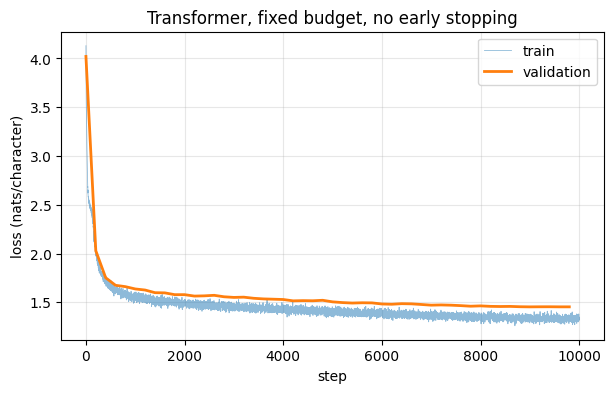

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(*zip(*train_losses), lw=0.6, alpha=0.5, label='train')
ax.plot(*zip(*val_losses), lw=2, label='validation')
ax.set_xlabel('step'); ax.set_ylabel('loss (nats/character)')
ax.set_title('Transformer, fixed budget, no early stopping')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# Load parameters from specific batch

In [20]:
# Sort by step number, not lexicographically: sorted() on the raw paths puts
# '-9000.pkl' after '-10000.pkl' and would load the wrong checkpoint.
paths = sorted(glob.glob("checkpoints/charlm/transformer-*.pkl"),
               key=lambda p: int(p.rsplit('-', 1)[1].removesuffix('.pkl')))
if not paths:
    raise FileNotFoundError("No Transformer checkpoint files found in checkpoints/")

latest = paths[-1]
print("Loading checkpoint:", latest)
with open(latest, 'rb') as file:
    params = pickle.load(file)

Loading checkpoint: checkpoints/charlm/transformer-10000.pkl


In [21]:
print(sample(params, 500, jax.random.key(21), prompt='ROMEO:'))

ROMEO:
To see they says thrust; tell our atched'st
For man the blood Biron, master!

MAMILLO:
O, skiss hath bliss!

GREGON:
I friar:
For the comes, or trimmade see in his babellious;
Fourth my discum, mortalling the reasons;
Many there's man?

OTHELLO:
Be convey, ring close news erseu have his horns are for
my same seen, such after Fenton thee.
For almost come to beholder.

CAMILLO:
My doorse, lord, thou didst.

JULIET:
Too was a discover'd it great parted ere wit
Dreabhors it stand to shall not


# Scoring the trained model

Same evaluator, same windows, same cold start as the baselines, the RNN and the GRU — then write the transformer's row of the comparison.

In [22]:
tf_logprob = jax.jit(lambda ids: jax.nn.log_softmax(batched_logits(params, ids)))

tf_bpc = evaluate_bpc(lambda x: tf_logprob(jnp.asarray(x)),
                      val_tokens, CONFIG['context_length'])
n_params = sum(a.size for a in jax.tree_util.tree_leaves(params))
assert abs(n_params / CONFIG['param_budget'] - 1) < 0.03, (
    f"{n_params:,} parameters is not within 3% of the shared budget "
    f"{CONFIG['param_budget']:,}: the comparison would not be capacity-controlled")

write_result('transformer', tf_bpc, n_params=n_params)
print(f'Transformer  {tf_bpc:.3f} bpc   ({n_params:,} parameters)')

Transformer  2.139 bpc   (493,699 parameters)


# Results so far

The last notebook in the sequence, so this table is the complete comparison — provided you have run `RNN.ipynb` and `GRU.ipynb`. Any model you have not run is named as `not run` rather than omitted, and the table refuses to render if two results disagree about the experiment they ran under.

Read it with the state policy in mind: all three models were trained and scored on cold 128-character windows, which is the only protocol a transformer can implement, and which costs the recurrent models the long-range context they would normally carry.

In [23]:
EXPECTED_MODELS = ['unigram', 'bigram', 'rnn', 'gru', 'transformer']
COMPARE_KEYS = ['val_hash', 'state_policy', 'context_length', 'steps',
                'batch_size', 'seed', 'param_budget']

def results_table():
    """Print the comparison from whatever result files exist.

    Rows produced under a different experiment are marked `stale` rather than
    raising: a table that refuses to render teaches nothing, and the rows that
    *are* comparable are still worth seeing. Models never run are named too, so
    the table can never look complete when it is not."""
    found = {}
    for path in sorted(glob.glob('checkpoints/charlm_result_*.json')):
        with open(path) as f:
            r = json.load(f)
        found[r['model']] = r

    if not found:
        print('No results yet. Run RNN.ipynb first.')
        return

    def signature(r):
        return tuple(str(r['manifest'].get(k)) for k in COMPARE_KEYS)

    counts = {}
    for r in found.values():
        counts[signature(r)] = counts.get(signature(r), 0) + 1
    current = max(counts, key=counts.get)          # the majority experiment
    ref = next(r for r in found.values() if signature(r) == current)['manifest']

    print(f"corpus {ref['corpus']} | context {ref['context_length']} | "
          f"state_policy {ref['state_policy']} | ~{ref['param_budget']:,} parameters "
          f"per model | seed {ref['seed']} (single run)")
    print()
    print(f"{'model':<14}{'bpc':>8}{'params':>12}")
    print('-' * 34)
    stale = []
    for name in EXPECTED_MODELS:
        r = found.get(name)
        if r is None:
            print(f"{name:<14}{'not run':>8}{'':>12}")
        elif signature(r) != current:
            print(f"{name:<14}{'stale':>8}{'':>12}")
            stale.append(name)
        else:
            p = r.get('n_params')
            print(f"{name:<14}{r['bpc']:>8.3f}{('' if p is None else f'{p:,}'):>12}")

    if stale:
        print()
        print(f"stale: {', '.join(stale)} ran under a different experiment. "
              'Re-run against the current charlm_config.json.')

results_table()

corpus data/shakespear3.txt | context 128 | state_policy none | ~493,699 parameters per model | seed 42 (single run)

model              bpc      params
----------------------------------
unigram          4.770            
bigram           3.581            
rnn              2.071     493,241
gru              2.023     493,747
transformer      2.139     493,699


# References

- [Vaswani et al. 2017](http://arxiv.org/abs/1706.03762): _Attention Is All You Need_, the fundamental paper on transformers.


# Exercises

The table above is a controlled experiment: same data, same split, same budget, same schedule, same state policy, same seed, and all three models within 0.1% of the same parameter count and one layer deep. Everything below breaks exactly one of those controls, on purpose.

**1. Buy depth with the parameters you have.** Set `CONFIG['tf_n_layers'] = 2` and re-run. That roughly doubles the model (blocks are ~97% of its parameters), so the comparison is no longer capacity-controlled — the assertion in the scoring cell will fire, which is the point. How much bpc does the second block buy, and is it more or less than you would get by spending the same parameters on width instead (one block, `d_model` raised until the counts match)? That second experiment *is* capacity-controlled, and it isolates depth from width.

**2. Do the same for the recurrent models.** Stack a second recurrent layer in `RNN.ipynb` or `GRU.ipynb` — feed the first layer's hidden state into the second instead of a character index. Note the cost is not symmetric: a second transformer block costs **1.9×** the one-block model, but a second recurrent layer costs about **2.6×**, because the first layer's input matrix is $h \times V$ with $V = 67$ while the second layer's is $h \times h$. Which architecture gets more out of the extra depth per parameter?

**3. Attention span.** Print the attention weights `w` from `self_attention` for a trained model on a sentence. Which positions does each head attend to? Is any head approximately a bigram model — attending only to the previous character?

**4. Context length.** `CONFIG['context_length']` is 128. Halve it and double it, re-running all three models each time. The recurrent models are handicapped by short windows (they normally carry state across the corpus) and the transformer is bounded by its window absolutely. Does the gap between them change with context length? This is the most interesting confound left in the experiment.

**5. KV cache.** `sample` recomputes every key and value at every step. Cache them: keep `K` and `V` buffers of shape `(n_heads, seq_length, d_head)` per block, write the new position, and attend over the prefix. Confirm greedy decoding produces *identical* characters, then measure the speedup.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)